## Importing Libraries and Packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz 

from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold, cross_validate
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

## EDA

In [4]:
# Importing and viewing data
df = pd.read_csv("CellphoneAddiction.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [5]:
# Droping ID columns and columns that would give away the target
drop = ["transaction_id", "user_id", "addiction_level"]
data = df.drop(columns = drop)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      7500 non-null   int64  
 1   gender                   7500 non-null   object 
 2   daily_screen_time_hours  7500 non-null   float64
 3   social_media_hours       7500 non-null   float64
 4   gaming_hours             7500 non-null   float64
 5   work_study_hours         7500 non-null   float64
 6   sleep_hours              7500 non-null   float64
 7   notifications_per_day    7500 non-null   int64  
 8   app_opens_per_day        7500 non-null   int64  
 9   weekend_screen_time      7500 non-null   float64
 10  stress_level             7500 non-null   object 
 11  academic_work_impact     7500 non-null   object 
 12  addicted_label           7500 non-null   int64  
dtypes: float64(6), int64(4), object(3)
memory usage: 761.8+ KB


In [6]:
# Making two new columns of the proportion of screen time each respondant spent on social media and gaming respectively
# Also making the leftover proportions other
data["social_media_proportion"] = round(data["social_media_hours"] / data["daily_screen_time_hours"], 2)
data["gaming_proportion"] = round(data["gaming_hours"] / data["daily_screen_time_hours"], 2)
data["other_proportion"] = 1 - data["social_media_proportion"] - data["gaming_proportion"]

In [7]:
# Ensuring not other_proportion is negative
print(f'Number of rows where other_proportion is negative: {len(data[data["other_proportion"] < 0])}')
# So there is a problem, 
print(f'{len(data[data["daily_screen_time_hours"] > data["weekend_screen_time"]])} rows have more daily_screen_time_hours than weekend_screen_time.')
print(f'{len(data[data["social_media_hours"] + data["gaming_hours"] > data["weekend_screen_time"]])} rows have more hours in social_media_hours and gaming_hours combined than weekend_screen_time.')

Number of rows where other_proportion is negative: 1961
0 rows have more daily_screen_time_hours than weekend_screen_time.
944 rows have more hours in social_media_hours and gaming_hours combined than weekend_screen_time.


In [8]:
# So something is wrong with the data and the number of social_media_hours and gaming_hours, which should happen with screens, adds up to
# more than daily_screen_time_hours in 1961 rows.
# Upon further inspections, there are also a bunch a rows with a value higher than 1 in either proportions, so we will scrap the idea.
data = data.drop(columns = ["other_proportion", "social_media_proportion", "gaming_proportion"])

In [112]:
# Finding the prevalence
prevalence = round(data["addicted_label"].sum() / len(data) * 100, 2)
print(f'The prevalence of the data is {prevalence}%')

The prevalence of the data is 70.77%


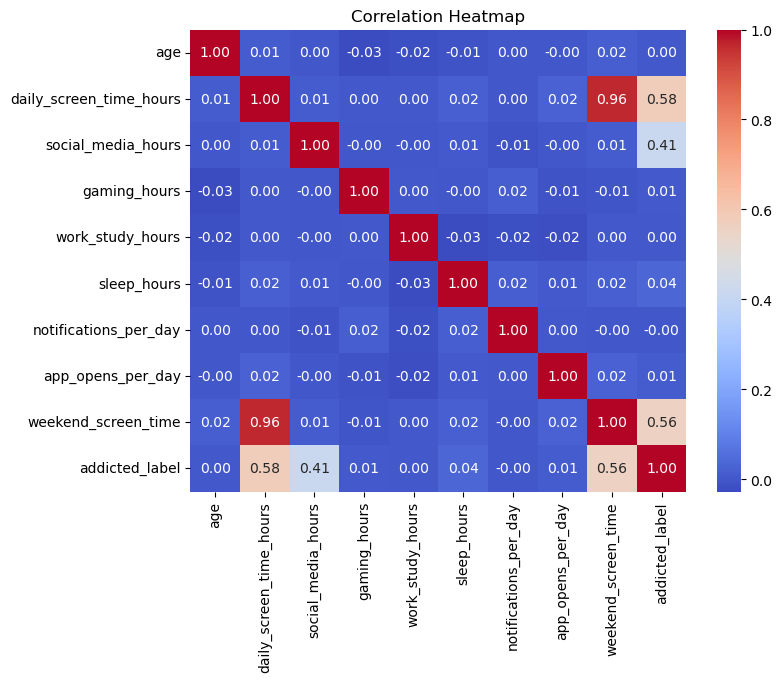

In [9]:
# Making a correlation heatmap to see other variable's correlation with the target
corr = data.select_dtypes('number').corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

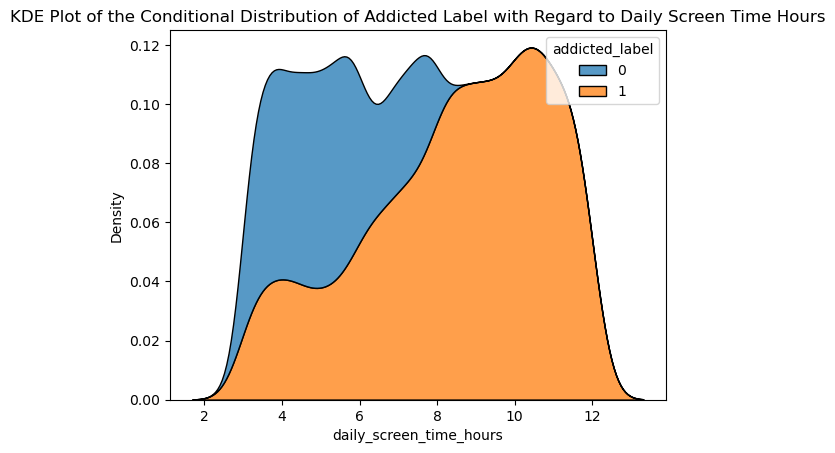

In [10]:
# Making a kde plot to visualize the relationship between daily_screen_time_hours and addicted_label
sns.kdeplot(data = data, x = "daily_screen_time_hours", hue = "addicted_label", multiple = "stack")
plt.title("KDE Plot of the Conditional Distribution of Addicted Label with Regard to Daily Screen Time Hours");

In [11]:
# Checking the categorical variables to see if there are small categories that needs to be collapsed
print(data["gender"].value_counts())
print(data["stress_level"].value_counts())
print(data["academic_work_impact"].value_counts())
# There does not seem to be any

gender
Male      2553
Other     2486
Female    2461
Name: count, dtype: int64
stress_level
High      2560
Low       2503
Medium    2437
Name: count, dtype: int64
academic_work_impact
No     3753
Yes    3747
Name: count, dtype: int64


<Axes: xlabel='academic_work_impact', ylabel='Proportion'>

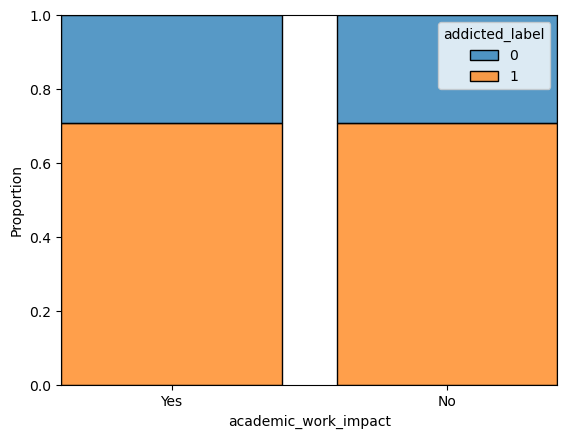

In [12]:
# We will visualize the target in relation to the categorical variables
sns.histplot(
    data=data,
    x="academic_work_impact", hue="addicted_label",
    multiple="fill", stat="proportion",
    discrete=True, shrink=.8
)


In [13]:
# A plot like the one above has been ran on every single categorical variable, and it seems that the positive class is evenly distributed
# within each category.
print(data[data["addicted_label"] == 1]["gender"].value_counts())
print(data[data["addicted_label"] == 1]["stress_level"].value_counts())
print(data[data["addicted_label"] == 1]["academic_work_impact"].value_counts())
# This indicate that there is no correlation between them and the target variable

gender
Male      1844
Other     1736
Female    1728
Name: count, dtype: int64
stress_level
High      1801
Low       1782
Medium    1725
Name: count, dtype: int64
academic_work_impact
No     2656
Yes    2652
Name: count, dtype: int64


## Model Prep and Data Split

In [15]:
# We will first try a decision tree model
X = data.drop(columns='addicted_label')
y = data.addicted_label

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.70, stratify= y, random_state=21)
X_tune, X_test, y_tune, y_test = train_test_split(X_test,y_test,  train_size = 0.50, stratify= y_test, random_state=49)

In [72]:
kf = RepeatedStratifiedKFold(n_splits=10,n_repeats =5, random_state=42)

param={"classifier__max_depth" : [1,2,3,4,5,6,7,8,9,10,11],
       #"classifier__splitter":["best","random"],
       #"classifier__min_samples_split":[5,10,15,20,25],
       #"classifier__min_samples_leaf":[5,10,15,20,25],
       #"classifier__max_features":["auto","log2","sqrt",None],
       #"classifier__max_leaf_nodes":[10,20,30,40,50],
       #"classifier__min_impurity_decrease":[0.00005,0.0001,0.0002,0.0005,0.001,0.0015,0.002],
       #"classifier__ccp_alpha" :[.001, .01, .1]
           }

scoring = ['roc_auc','recall','balanced_accuracy']

In [74]:
categorical_features = X.select_dtypes(include='object').columns.tolist() 
pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('ordinal', OrdinalEncoder(), categorical_features)
        ],
        remainder='passthrough'
    )),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

search = GridSearchCV(pipeline, param, scoring=scoring, n_jobs=-1, cv=kf, refit='roc_auc')
model = search.fit(X_train, y_train)

In [75]:
best = model.best_estimator_
print(best)
best_clf = best.named_steps['classifier']
print('\nBest max_depth:', best_clf.max_depth)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal', OrdinalEncoder(),
                                                  ['gender', 'stress_level',
                                                   'academic_work_impact'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=3, random_state=42))])

Best max_depth: 3


In [78]:
#Scores:
# model.cv_results_['mean_test_roc_auc'][np.where((model.cv_results_['param_ccp_alpha'] == .001))]
auc     = model.cv_results_['mean_test_roc_auc']
recall  = model.cv_results_['mean_test_recall']
bal_acc = model.cv_results_['mean_test_balanced_accuracy']

SDauc     = model.cv_results_['std_test_roc_auc']
SDrecall  = model.cv_results_['std_test_recall']
SDbal_acc = model.cv_results_['std_test_balanced_accuracy']

#Parameter: note the key is now 'param_classifier__max_depth' because we are using a pipeline
depth = np.unique(model.cv_results_['param_classifier__max_depth']).data

#Build DataFrame:
final_model = pd.DataFrame(list(zip(depth, auc, recall, bal_acc, SDauc, SDrecall, SDbal_acc)),
               columns=['depth','auc','recall','bal_acc','aucSD','recallSD','bal_accSD'])

#Let's take a look
print(final_model.to_string(index=False))

 depth      auc   recall  bal_acc    aucSD  recallSD  bal_accSD
     1 0.814014 0.630508 0.814014 0.013045  0.025783   0.013045
     2 0.956200 0.914423 0.955972 0.007301  0.013932   0.007370
     3 0.988323 0.914423 0.955972 0.002782  0.013932   0.007370
     4 0.987742 0.928679 0.937189 0.003640  0.030672   0.026370
     5 0.987229 0.943869 0.927162 0.003915  0.023286   0.023709
     6 0.986478 0.939233 0.926910 0.003981  0.024087   0.020239
     7 0.985297 0.943381 0.927883 0.004850  0.017617   0.018797
     8 0.980578 0.949084 0.921276 0.007583  0.020191   0.018135
     9 0.975264 0.951025 0.919521 0.009191  0.016364   0.016263
    10 0.968564 0.951239 0.919364 0.011009  0.016730   0.015987
    11 0.959234 0.951939 0.918803 0.012264  0.015721   0.014527


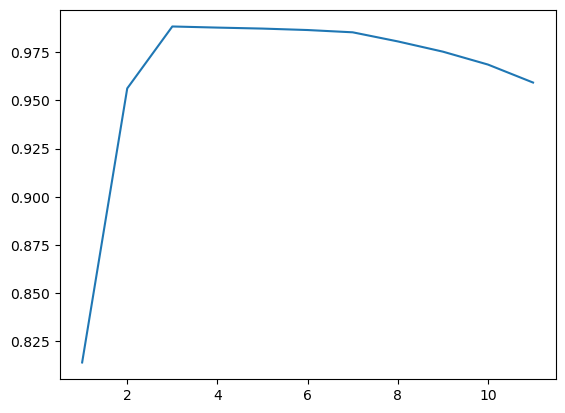

In [82]:
print(plt.plot(final_model.depth,final_model.auc))

In [87]:
varimp = pd.DataFrame(
    best.named_steps['classifier'].feature_importances_,
    index=X.columns,
    columns=['importance']
).sort_values('importance', ascending=False)

print(varimp)

                         importance
work_study_hours           0.506705
gaming_hours               0.492197
academic_work_impact       0.001098
age                        0.000000
gender                     0.000000
daily_screen_time_hours    0.000000
social_media_hours         0.000000
sleep_hours                0.000000
notifications_per_day      0.000000
app_opens_per_day          0.000000
weekend_screen_time        0.000000
stress_level               0.000000


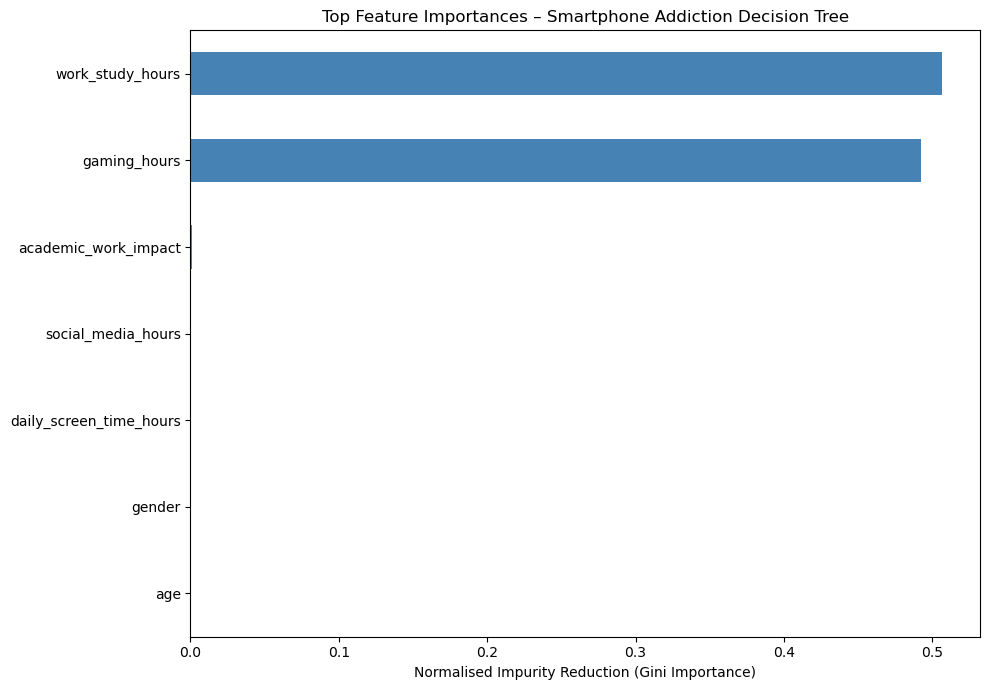

In [92]:
ig, ax = plt.subplots(figsize=(10, 7))
varimp.importance.nlargest(7).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Normalised Impurity Reduction (Gini Importance)')
ax.set_title('Top Feature Importances – Smartphone Addiction Decision Tree')
plt.tight_layout()
plt.show()

In [95]:
# ── Stage 1: Cross-validation scores from GridSearchCV (on the training set) ──
print('=== Stage 1: Cross-Validation Scores (training folds) ===')
print(f"  Best max_depth : {model.best_params_['classifier__max_depth']}")
print(f"  CV AUC         : {model.best_score_:.4f}")

# Cross-validate the best pipeline on the training set for a detailed score breakdown
cv_results = cross_validate(
    best, X_train, y_train,
    cv=kf,
    scoring=scoring,
    return_train_score=True
)
print('\n  Detailed CV score summary (training set):')
for metric in ['roc_auc', 'recall', 'balanced_accuracy']:
    train_scores = cv_results[f'train_{metric}']
    test_scores  = cv_results[f'test_{metric}']
    print(f"    {metric:<20s}  train={train_scores.mean():.4f}±{train_scores.std():.4f}  "
          f"val={test_scores.mean():.4f}±{test_scores.std():.4f}")

=== Stage 1: Cross-Validation Scores (training folds) ===
  Best max_depth : 3
  CV AUC         : 0.9883

  Detailed CV score summary (training set):
    roc_auc               train=0.9890±0.0003  val=0.9883±0.0028
    recall                train=0.9144±0.0015  val=0.9144±0.0139
    balanced_accuracy     train=0.9566±0.0008  val=0.9560±0.0074


=== Stage 2: Validation-Set Evaluation ===
  AUC               : 0.9869
  Recall (TPR)      : 0.9058
  Balanced Accuracy : 0.9514

Validation Confusion Matrix:


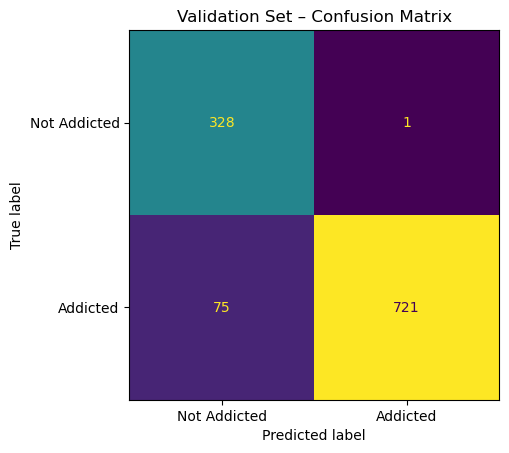

In [100]:
# ── Stage 2: Evaluate the best pipeline on the held-out validation (tuning) set ──
print('=== Stage 2: Validation-Set Evaluation ===')

y_val_pred  = best.predict(X_tune)
y_val_proba = best.predict_proba(X_tune)[:, 1]

val_auc  = metrics.roc_auc_score(y_tune, y_val_proba)
val_rec  = metrics.recall_score(y_tune, y_val_pred)
val_bacc = metrics.balanced_accuracy_score(y_tune, y_val_pred)

print(f'  AUC               : {val_auc:.4f}')
print(f'  Recall (TPR)      : {val_rec:.4f}')
print(f'  Balanced Accuracy : {val_bacc:.4f}')

print('\nValidation Confusion Matrix:')
ConfusionMatrixDisplay.from_estimator(best, X_tune, y_tune,
                                      display_labels=['Not Addicted','Addicted'],
                                      colorbar=False)
plt.title('Validation Set – Confusion Matrix')
plt.show()

In [ ]:
# ── Stage 3: Final evaluation on the held-out test set ──────────────────────
# print('=== Stage 3: Test-Set Evaluation (final) ===')

# y_test_pred  = best.predict(X_test)
# y_test_proba = best.predict_proba(X_test)[:, 1]

# test_auc  = metrics.roc_auc_score(y_test, y_test_proba)
# test_rec  = metrics.recall_score(y_test, y_test_pred)
# test_bacc = metrics.balanced_accuracy_score(y_test, y_test_pred)
# test_acc  = metrics.accuracy_score(y_test, y_test_pred)

# print(f'  AUC               : {test_auc:.4f}')
# print(f'  Recall (TPR)      : {test_rec:.4f}')
# print(f'  Balanced Accuracy : {test_bacc:.4f}')
# print(f'  Accuracy          : {test_acc:.4f}')

# print('\nTest Confusion Matrix:')
# ConfusionMatrixDisplay.from_estimator(best, X_test, y_test,
#                                       display_labels=['ave','excellent'],
#                                       colorbar=False)
# plt.title('Test Set – Confusion Matrix (Final Evaluation)')
# plt.show()

# print('\nROC Curve (Test Set):')
# metrics.RocCurveDisplay.from_predictions(y_test, y_test_proba)
# plt.plot([0, 1], [0, 1], 'r--')
# plt.title(f'ROC Curve – Test Set  (AUC = {test_auc:.3f})')
# plt.show()

In [117]:
print("testing")

testing
